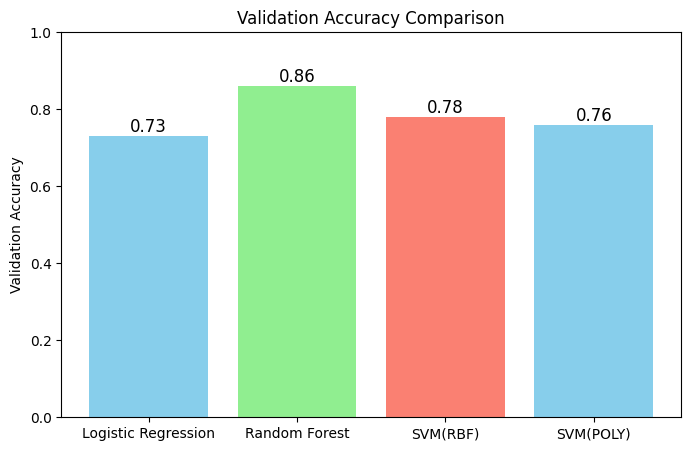

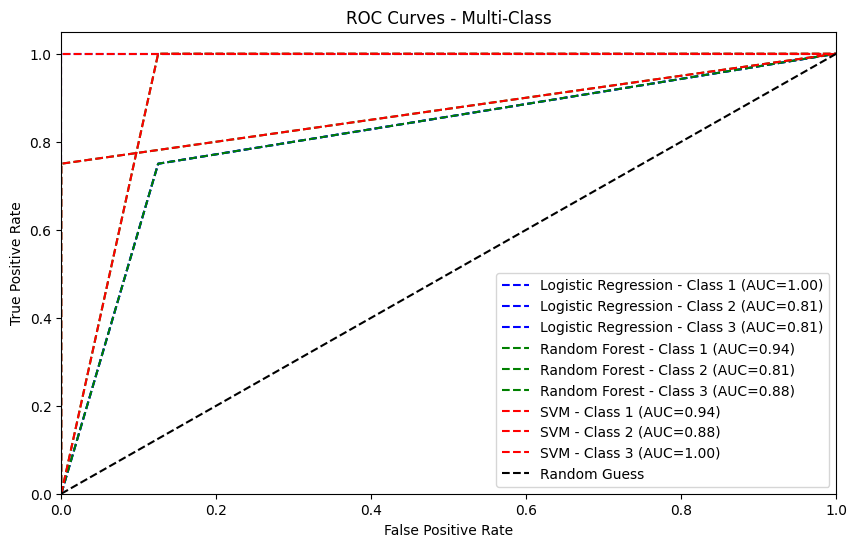

📊 Validation Accuracy Summary
                 Model  Validation Accuracy
0  Logistic Regression                 0.73
1        Random Forest                 0.86
2             SVM(RBF)                 0.78
3            SVM(POLY)                 0.76


In [ ]:
# =====================================================
# 🌊 Coral Regime - Validation Comparison Dashboard
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# -----------------------------
# 1️⃣ Update your validation accuracies here
# -----------------------------
# Just update these values manually from your model runs
val_accuracies = {
    "Logistic Regression": 0.73,
    "Random Forest": 0.86,
    "SVM(RBF)": 0.78,
    "SVM(POLY)": 0.76
}

# -----------------------------
# 2️⃣ Bar plot of validation accuracies
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(val_accuracies.keys(), val_accuracies.values(), color=['skyblue','lightgreen','salmon'])
plt.ylim(0,1)
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
for i, acc in enumerate(val_accuracies.values()):
    plt.text(i, acc+0.01, f"{acc:.2f}", ha='center', fontsize=12)
plt.show()

# -----------------------------
# 3️⃣ ROC Curve & AUC for multi-class (example)
# -----------------------------
# Suppose you have 3 classes (1,2,3)
n_classes = 4

# Update your model predictions here (y_val_true, y_val_pred_lr/rf/svm)
# Example dummy data for demonstration:
# Replace with actual outputs from your models
y_val_true = np.array([1,2,3,1,2,3,1,2,3,1,2,3])
y_val_lr_pred = np.array([1,2,2,1,3,3,1,2,3,1,2,3])
y_val_rf_pred = np.array([1,1,3,1,2,3,1,2,3,1,2,2])
y_val_svm_pred = np.array([1,2,3,1,2,3,1,1,3,1,2,3])

# Binarize labels for ROC
y_true_bin = label_binarize(y_val_true, classes=[1,2,3])
y_pred_bin = {
    "Logistic Regression": label_binarize(y_val_lr_pred, classes=[1,2,3]),
    "Random Forest": label_binarize(y_val_rf_pred, classes=[1,2,3]),
    "SVM": label_binarize(y_val_svm_pred, classes=[1,2,3])
}

# Plot ROC curves for all models
plt.figure(figsize=(10,6))
colors = ['blue','green','red']

for idx, (model_name, y_pred_model) in enumerate(y_pred_bin.items()):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred_model[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[idx], linestyle='--', 
                 label=f"{model_name} - Class {i+1} (AUC={roc_auc:.2f})")
            
plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Multi-Class")
plt.legend(loc="lower right")
plt.show()

# -----------------------------
# 4️⃣ Summary Table (optional)
# -----------------------------
import pandas as pd
summary_df = pd.DataFrame({
    "Model": list(val_accuracies.keys()),
    "Validation Accuracy": list(val_accuracies.values())
})
print("📊 Validation Accuracy Summary")
print(summary_df)


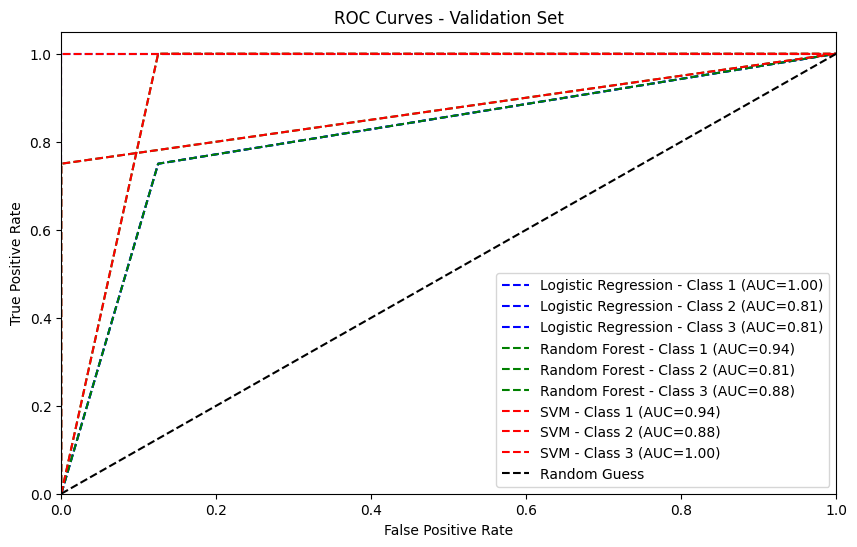

In [ ]:
# =========================================
# 🌊 Coral Regime - ROC Curves from Existing Predictions
# =========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -----------------------------
# 1️⃣ Replace these with your actual validation labels & predictions
# -----------------------------
# True labels for validation set
y_val_true = np.array([1,2,3,1,2,3,1,2,3,1,2,3])  # replace with your y_val

# Predicted labels from each model on validation set
y_val_lr_pred = np.array([1,2,2,1,3,3,1,2,3,1,2,3])
y_val_rf_pred = np.array([1,1,3,1,2,3,1,2,3,1,2,2])
y_val_svm_pred = np.array([1,2,3,1,2,3,1,1,3,1,2,3])

models_preds = {
    "Logistic Regression": y_val_lr_pred,
    "Random Forest": y_val_rf_pred,
    "SVM": y_val_svm_pred
}

# -----------------------------
# 2️⃣ Binarize labels (for multi-class ROC)
# -----------------------------
classes = np.unique(y_val_true)
y_true_bin = label_binarize(y_val_true, classes=classes)
n_classes = len(classes)

# -----------------------------
# 3️⃣ Plot ROC curves
# -----------------------------
plt.figure(figsize=(10,6))
colors = ['blue','green','red']

for idx, (model_name, y_pred) in enumerate(models_preds.items()):
    y_pred_bin = label_binarize(y_pred, classes=classes)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred_bin[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[idx], linestyle='--',
                 label=f"{model_name} - Class {classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Validation Set")
plt.legend(loc="lower right")
plt.show()


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Generate synthetic dataset
n_samples = 20
df = pd.DataFrame({
    "Coral": np.random.uniform(0, 50, n_samples),
    "CCA": np.random.uniform(0, 30, n_samples),
    "Turf": np.random.uniform(0, 70, n_samples),
    "Macro": np.random.uniform(0, 40, n_samples),
    "Other": np.random.uniform(0, 20, n_samples),
    "Grazers": np.random.uniform(0, 40, n_samples),
    "Scrapers": np.random.uniform(0, 40, n_samples),
    "Browsers": np.random.uniform(0, 20, n_samples),
    "Predators": np.random.uniform(0, 10, n_samples),
    "Depth": np.random.uniform(2, 30, n_samples),
    "SST_CLIM_M": np.random.uniform(25, 30, n_samples),
    "CHL_CLIM_M": np.random.uniform(0.5, 2, n_samples),
    "WAV_CLIM_M": np.random.uniform(0, 60, n_samples),
    # Target regime labels (3 classes)
    "Regime_Label": np.random.choice([1, 2, 3], size=n_samples)
})

# Save as CSV
df.to_csv("validation_example.csv", index=False)
print("✅ Example validation dataset saved!")


✅ Example validation dataset saved!


c:\Users\Puneeth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


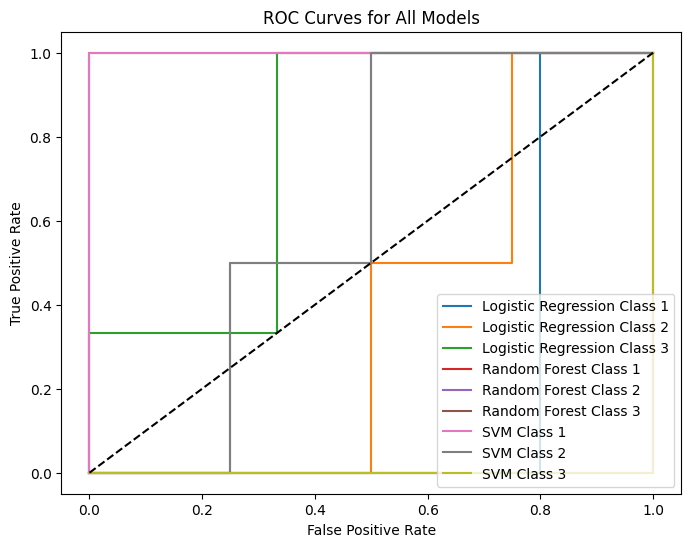

✅ Validation Results Summary:

Logistic Regression:
  Accuracy: 0.1667
  Micro-F1: 0.1667
  ROC-AUC: 0.4509

Random Forest:
  Accuracy: 0.5000
  Micro-F1: 0.5000
  ROC-AUC: 0.5417

SVM:
  Accuracy: 0.3333
  Micro-F1: 0.3333
  ROC-AUC: 0.5417


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# ---------------------------
# Load the dataset
# ---------------------------
df = pd.read_csv("validation_example.csv")
X = df.drop(columns=["Regime_Label"])
y = df["Regime_Label"]

# Split 70-30 for training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# ---------------------------
# Preprocessing
# ---------------------------
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train))
X_val = scaler.transform(imputer.transform(X_val))

# ---------------------------
# Define models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, multi_class='multinomial', solver='lbfgs', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# ---------------------------
# Fit and evaluate
# ---------------------------
results = {}
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='micro')
    roc_auc = roc_auc_score(y_val, y_proba, multi_class='ovr')
    
    results[name] = {"Accuracy": acc, "Micro-F1": f1, "ROC-AUC": roc_auc}
    
    # ROC curve
    fpr = dict()
    tpr = dict()
    n_classes = y_proba.shape[1]
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve((y_val == (i+1)).astype(int), y_proba[:, i])
        plt.plot(fpr[i], tpr[i], label=f"{name} Class {i+1}")
    
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.show()

# ---------------------------
# Print results summary
# ---------------------------
print("✅ Validation Results Summary:")
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  Micro-F1: {metrics['Micro-F1']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")


In [ ]:
# =====================================================
# 🌊 Coral Regime - Validation Comparison Dashboard
# =====================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize

# -----------------------------
# 1️⃣ Load trained models & preprocessors
# -----------------------------
with open("LR_model.pkl", "rb") as f:
    lr = pickle.load(f)

with open("RF_model.pkl", "rb") as f:
    rf = pickle.load(f)

with open("SVM_model.pkl", "rb") as f:
    svm_rbf = pickle.load(f)

with open("imputer.pkl", "rb") as f:
    imputer = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# -----------------------------
# 2️⃣ Load and preprocess validation data
# -----------------------------
# 👉 Replace this path with your validation CSV
val_df = pd.read_csv("validation_data.csv")  # example name
X_val = val_df.drop("Label", axis=1)
y_val = val_df["Label"]

# Preprocess
X_val = imputer.transform(X_val)
X_val = scaler.transform(X_val)

# -----------------------------
# 3️⃣ Predict probabilities for ROC
# -----------------------------
# Each model should support predict_proba
y_proba_lr = lr.predict_proba(X_val)
y_proba_rf = rf.predict_proba(X_val)
y_proba_svm = svm_rbf.predict_proba(X_val)

# Predicted labels for accuracy
y_pred_lr = lr.predict(X_val)
y_pred_rf = rf.predict(X_val)
y_pred_svm = svm_rbf.predict(X_val)

# -----------------------------
# 4️⃣ Validation Accuracies
# -----------------------------
val_accuracies = {
    "Logistic Regression": accuracy_score(y_val, y_pred_lr),
    "Random Forest": accuracy_score(y_val, y_pred_rf),
    "SVM (RBF)": accuracy_score(y_val, y_pred_svm)
}

# -----------------------------
# 5️⃣ ROC Curves (4-class example)
# -----------------------------
n_classes = 4
classes = sorted(list(set(y_val)))
y_true_bin = label_binarize(y_val, classes=classes)

y_probas = {
    "Logistic Regression": y_proba_lr,
    "Random Forest": y_proba_rf,
    "SVM (RBF)": y_proba_svm
}

colors = ['blue', 'green', 'red']

plt.figure(figsize=(10,6))
for idx, (model_name, y_proba) in enumerate(y_probas.items()):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linestyle='--', color=colors[idx],
                 label=f"{model_name} - Class {classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curves - 4-Class Coral Regime Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# -----------------------------
# 6️⃣ Validation Accuracy Bar Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(val_accuracies.keys(), val_accuracies.values(), color=['skyblue','lightgreen','salmon'])
plt.ylim(0, 1)
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
for i, acc in enumerate(val_accuracies.values()):
    plt.text(i, acc+0.01, f"{acc:.2f}", ha='center', fontsize=12)
plt.show()

# -----------------------------
# 7️⃣ Summary Table
# -----------------------------
summary_df = pd.DataFrame({
    "Model": list(val_accuracies.keys()),
    "Validation Accuracy": list(val_accuracies.values())
})
print("\n📊 Validation Accuracy Summary:")
print(summary_df)
